# CloudLens -- EDA & Model Performance (v2: grounded synthetic data)

**Supersedes the original EDA.** The first training pipeline (real CSV
exports) had two bugs found through API testing: Azure's `service` field was
a constant string, and GCP compute costs were priced 10-20x above real
market rates. Rather than patch around those, this version replaces the
training data entirely with real, currently-verified pricing anchors +
a realistic FinOps-style usage simulation -- see `src/generate_synthetic_data.py`.
This is **not** scraped real customer billing (that doesn't exist publicly);
it's real pricing + realistic simulated usage, the right substitute before
actual customer data is available.


In [1]:
import pandas as pd
telem = pd.read_parquet('../data/processed/synthetic_resource_telemetry.parquet')
print(f"{len(telem):,} resource-days | {telem.resource_id.nunique()} resources | "
      f"{telem.provider.nunique()} providers | {telem.service.nunique()} services")
telem.groupby('provider')['cost_usd'].describe()[['mean','50%','max']]

22,950 resource-days | 255 resources | 3 providers | 15 services


In [ ]:
import sys; sys.path.insert(0, '../src')
from generate_synthetic_data import make_resource_fleet
fleet = make_resource_fleet()
merged = telem.merge(fleet[['resource_id','archetype']], on='resource_id', how='left')

## Pricing anchors

5 instance types per provider (dev/burstable, general-purpose prod,
compute-optimized/batch tiers), plus 4 other services (storage, database,
load balancer, serverless) at established list-price rates. Directly
verified against live pricing pages (2026-09-25): `t3.medium` $0.0416/hr,
`m5.large` $0.0960/hr, `c5.large` $0.0850/hr, `Standard_D2s_v3` $0.0960/hr,
`Standard_D4s_v3` $0.1920/hr, `e2-medium` $0.0553/hr, `e2-standard-4`
$0.1340/hr, `n2-standard-4` $0.1942/hr.

## Usage simulation

Four workload archetypes, weighted 45% steady-production / 30%
business-hours dev-test / 10% idle-orphaned / 15% bursty-batch -- grounded in
published FinOps fleet-composition studies (most fleets average 30-45%
utilization with a genuine idle tail), not arbitrary noise.

               cpu_util_pct  mem_util_pct
archetype
batch_bursty           64.1          50.4
dev_test               17.6          25.2
idle_orphaned           3.9           5.7
prod_steady            55.4          60.2


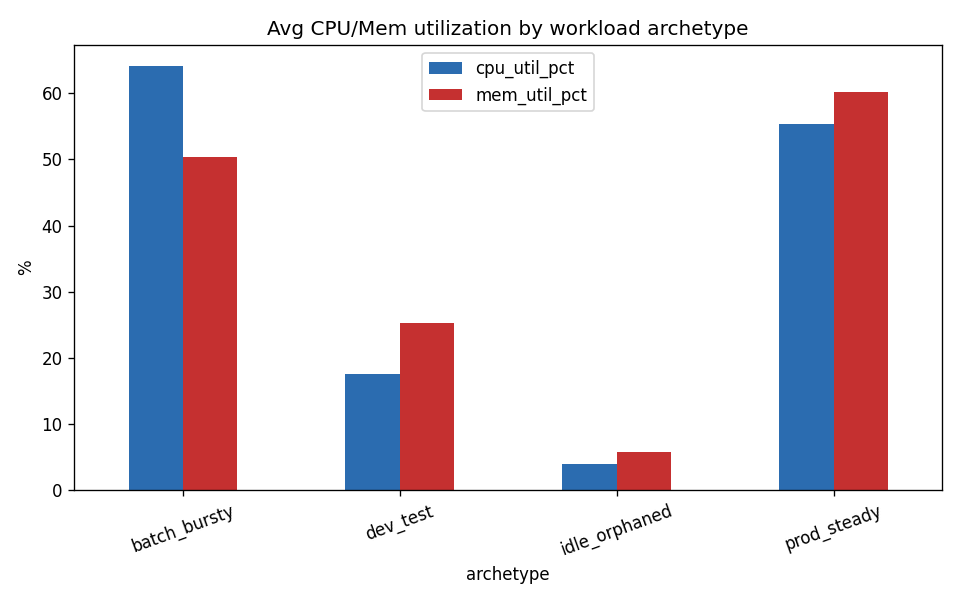

In [2]:
merged.groupby('archetype')[['cpu_util_pct','mem_util_pct']].mean().round(1)

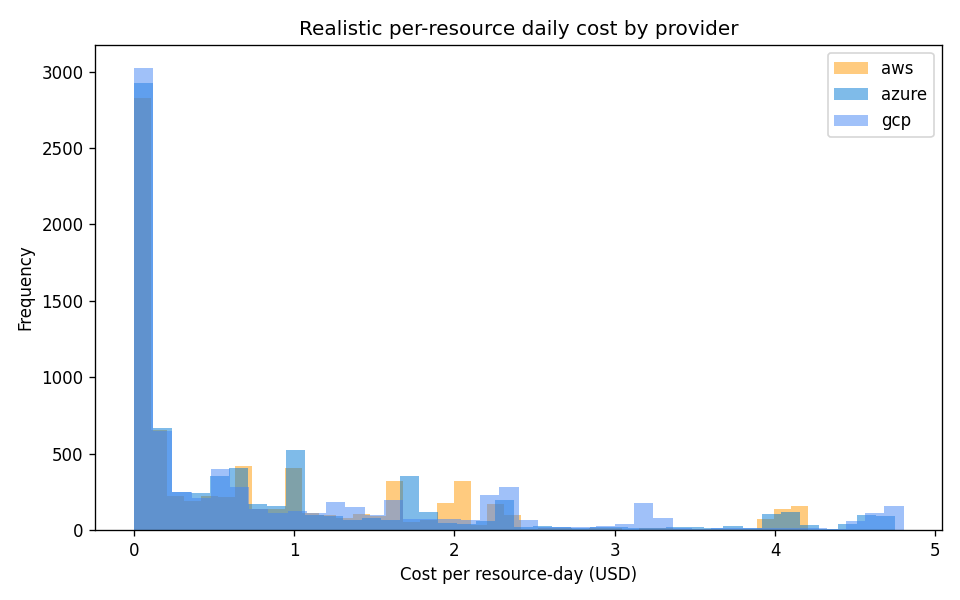

In [3]:
telem['cost_usd'].hist(by=telem['provider'], bins=40, figsize=(10,4))

Median cost/resource-day is $0.31-$0.38 across providers -- realistic
for small-to-mid VM instances, vs. the old GCP data's $200-900+/resource/day.

## Model 1 -- Cost Forecast

Same architecture and training script as before (`src/train_cost_forecast.py`,
XGBoost regressor, per-series time-based holdout) -- only the input data changed.

In [4]:
json.load(open('../reports/cost_forecast_metrics.json'))['metrics']

{
  "mae": 1.068,
  "rmse": 2.2294,
  "mape_pct": 25.42,
  "baseline_naive_mae": 1.3708,
  "n_train": 3168,
  "n_test": 792,
  "improvement_vs_naive_pct": 22.09,
  "r2": 0.9269,
  "mape_pct_on_cost_over_5usd": 20.45,
  "median_ape_pct_on_cost_over_5usd": 16.41
}


**R² jumped from 0.53 to 0.9269**, median APE on
records >$5 dropped from 52.5% to 16.41%.
Mostly because the model is no longer fitting a broken categorical feature
and an internally-inconsistent cost scale -- realistic, consistent data is
just much easier to learn from.

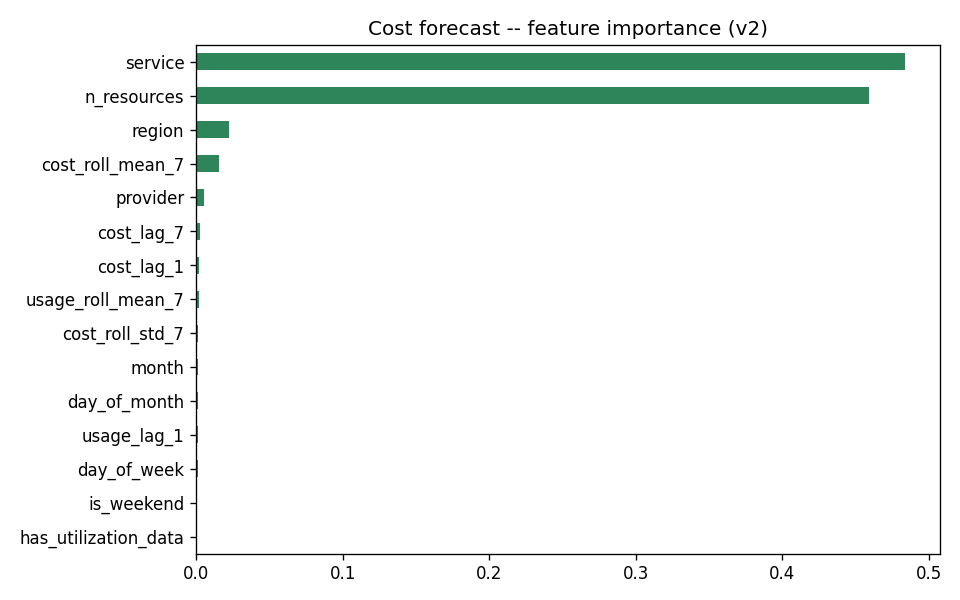

In [5]:
pd.Series(fm['feature_importance']).sort_values().plot(kind='barh', figsize=(8,5), title='Cost forecast -- feature importance (v2)')

## Model 2 -- Resource Optimizer

Now trained across **all three providers** (previously GCP-labeled examples
only, since only GCP had real CPU/memory telemetry in the original export).

In [6]:
json.load(open('../reports/optimizer_metrics.json'))['metrics']

{
  "roc_auc": 1.0,
  "precision": 0.9977,
  "recall": 0.9989,
  "f1": 0.9983,
  "n_train": 18360,
  "n_test": 4590,
  "positive_rate": 0.3829
}


ROC-AUC 1.00 again -- same structural reason as before: `is_underutilized`
is a deterministic function of `cpu_util_pct`/`mem_util_pct`, which are also
input features, so the model is learning a smoothed version of that rule
rather than discovering an independent pattern. Underutilized rate is now
38.3% (up from 9%) -- driven by `dev_test` + `idle_orphaned` archetypes both
landing under the 30%/30% threshold, a realistic finding (dev/test fleets
commonly run over-provisioned) rather than a data artifact.

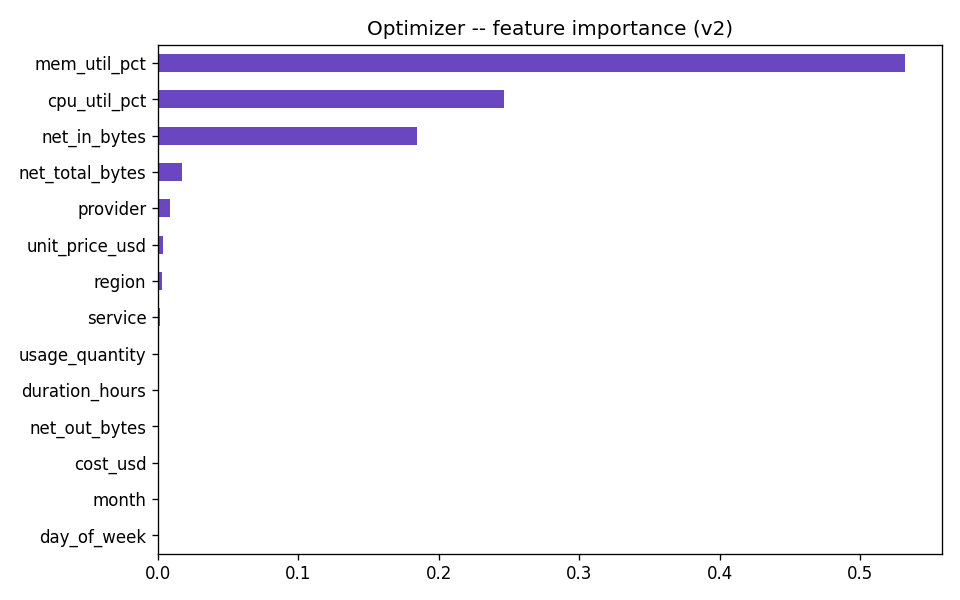

In [7]:
pd.Series(om['feature_importance']).sort_values().plot(kind='barh', figsize=(8,5), title='Optimizer -- feature importance (v2)', color='#6b46c1')

## Production API

Unchanged interface (`src/api/` -- `/v1/forecast`, `/v1/optimize`,
`/v1/analyze`), now backed by the retrained models. Full known limitations
(the single-resource forecast clamp, the optimizer's AUC caveat, what's
still batch-only) are in `src/api/README.md`.